# Vertical discretization

- **REF84** — existing 84-level benchmark.
- **V42-deep** — preserves the 25 × 2 m upper 50 m exactly; deep resolution is reduced aggressively.
- **V36** — 12 × 4 m in the upper 48 m.
- **V30** — 8 × 6 m in the upper 48 m.
- **V24** — 6 × 8 m in the upper 48 m.
- **V18** — 4 × 12.5 m in the upper 50 m.
- **V15** — extreme/failure-bracketing case with approximately 3 × 16.67 m in the upper 50 m.

Every array has a nominal total vertical extent of **4053.5 m**. Successive layer-thickness increases remain below 50% in all proposed reduced grids.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

## Vertical-grid definitions

In [2]:
REF84 = np.array([
    2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 2.0, 2.0, 2.2, 2.4, 2.6, 2.9, 3.1,
    3.4, 3.7, 4.0, 4.4, 4.8, 5.2, 5.7, 6.2, 6.8, 7.4,
    8.1, 8.8, 9.6, 10.5, 11.4, 12.5, 13.6, 14.8, 16.2, 17.6,
    19.2, 21.0, 22.9, 24.9, 27.2, 29.7, 32.4, 35.4, 38.6, 42.1,
    45.9, 50.0, 54.5, 59.4, 64.8, 70.6, 77.0, 84.0, 91.5, 99.7,
    108.7, 118.5, 129.1, 140.8, 153.5, 167.3, 182.4, 198.8, 216.7, 236.2,
    257.5, 280.7, 306.1, 328.5
], dtype=float)

V42_DEEP = np.array([
    *([2.0] * 25),
    2.200,
    3.282, 4.895, 7.301, 10.890,
    16.244, 24.230, 36.141, 53.908,
    80.410, 119.940, 178.903, 266.853,
    398.039, 593.717, 885.592, 1320.955
], dtype=float)

V36 = np.array([
    *([4.0] * 12),
    4.400, 4.840, 5.324,
    6.784, 8.645, 11.016, 14.037, 17.887,
    22.792, 29.043, 37.009, 47.159, 60.093,
    76.574, 97.575, 124.336, 158.437, 201.889,
    257.260, 327.816, 417.723, 532.289,
    678.274, 864.298
], dtype=float)

V30 = np.array([
    *([6.0] * 8),
    6.600, 7.260,
    9.214, 11.694, 14.842, 18.838,
    23.908, 30.344, 38.511, 48.878,
    62.035, 78.733, 99.926, 126.823,
    160.961, 204.288, 259.278, 329.069,
    417.646, 530.067, 672.748, 853.837
], dtype=float)

V24 = np.array([
    *([8.0] * 6),
    8.800, 9.680,
    12.947, 17.318, 23.164, 30.982,
    41.441, 55.429, 74.139, 99.164,
    132.637, 177.409, 237.293, 317.391,
    424.526, 567.825, 759.494, 1015.861
], dtype=float)

V18 = np.array([
    *([12.5] * 4),
    13.750,
    19.352, 27.235, 38.330, 53.946,
    75.923, 106.852, 150.383, 211.647,
    297.869, 419.217, 590.001, 830.359,
    1168.636
], dtype=float)

V15 = np.array([
    *([16.667] * 3),
    18.333,
    27.004, 39.774, 58.585, 86.291,
    127.101, 187.211, 275.748, 406.157,
    598.240, 881.164, 1297.891
], dtype=float)

GRIDS = {
    "REF84": REF84,
    "V42-deep": V42_DEEP,
    "V36": V36,
    "V30": V30,
    "V24": V24,
    "V18": V18,
    "V15": V15,
}

In [3]:
REFERENCE_NR = len(REF84)
TARGET_DEPTH = REF84.sum()

print(f"{'Grid':<10} {'Nr':>4} {'Depth [m]':>12} {'Reduction':>12} {'Max increase':>14}")
print("-" * 58)

for name, delR in GRIDS.items():
    growth = delR[1:] / delR[:-1] - 1.0
    reduction = 1.0 - len(delR) / REFERENCE_NR

    print(
        f"{name:<10} "
        f"{len(delR):>4d} "
        f"{delR.sum():>12.1f} "
        f"{100*reduction:>11.1f}% "
        f"{100*np.max(growth):>13.1f}%"
    )

    assert np.isclose(delR.sum(), TARGET_DEPTH, atol=1e-8)
    assert np.max(growth) <= 0.50 + 1e-12

print("\nAll grids have the same nominal vertical extent and stay within the 50% maximum-growth criterion.")

Grid         Nr    Depth [m]    Reduction   Max increase
----------------------------------------------------------
REF84        84       4053.5         0.0%          11.5%
V42-deep     42       4053.5        50.0%          49.2%
V36          36       4053.5        57.1%          27.4%
V30          30       4053.5        64.3%          26.9%
V24          24       4053.5        71.4%          33.8%
V18          18       4053.5        78.6%          40.7%
V15          15       4053.5        82.1%          47.3%

All grids have the same nominal vertical extent and stay within the 50% maximum-growth criterion.


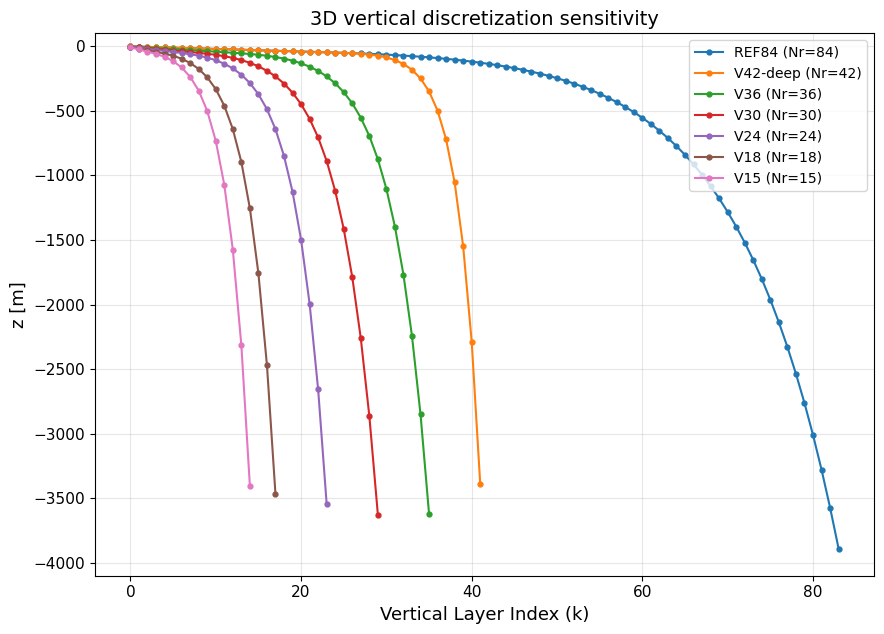

In [4]:
def cell_center_depths(delR):
    delR = np.asarray(delR, dtype=float)
    return -(np.cumsum(delR) - 0.5 * delR)


fig, ax = plt.subplots(figsize=(9.0, 6.5))

for name, delR in GRIDS.items():
    k = np.arange(len(delR))
    z = cell_center_depths(delR)
    ax.plot(k, z, marker="o", markersize=3.5, linewidth=1.5, label=f"{name} (Nr={len(delR)})")

ax.set_title("3D vertical discretization sensitivity")
ax.set_xlabel("Vertical Layer Index (k)")
ax.set_ylabel("z [m]")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", frameon=True)
ax.set_ylim(-4100, 100)

fig.tight_layout()
plt.show()

## Upper-ocean zoom

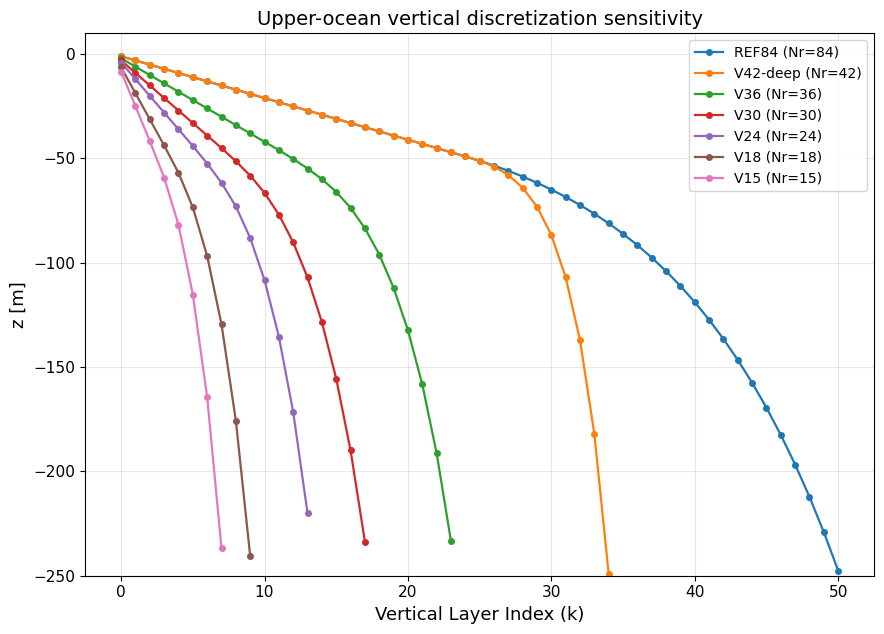

In [5]:
fig, ax = plt.subplots(figsize=(9.0, 6.5))

for name, delR in GRIDS.items():
    k = np.arange(len(delR))
    z = cell_center_depths(delR)
    mask = z >= -250.0
    ax.plot(k[mask], z[mask], marker="o", markersize=4.0, linewidth=1.6, label=f"{name} (Nr={len(delR)})")

ax.set_title("Upper-ocean vertical discretization sensitivity")
ax.set_xlabel("Vertical Layer Index (k)")
ax.set_ylabel("z [m]")
ax.set_ylim(-250, 10)
ax.grid(True, alpha=0.3)
ax.legend(loc="best", frameon=True)

fig.tight_layout()
plt.show()